In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
pd.read_csv("Remote_Work_AI_2026.csv")
remote_df=pd.read_csv("Remote_Work_AI_2026.csv")


In [ ]:
remote_df.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Work_Location,AI_Tools_Used,Weekly_Work_Hours,Productivity_Score,Wellbeing_Score,Commute_Time_Min
0,EMP001,28,Female,Data Analyst,Tech,Remote,ChatGPT;Copilot,40,8.5,9.0,0
1,EMP002,35,Male,Software Engineer,Finance,Hybrid,Cursor;DeepSeek,45,9.2,7.5,30
2,EMP003,42,Non-binary,HR Manager,Healthcare,On-site,NaN,38,6.0,5.5,60
3,EMP004,24,Male,Marketing Spec,Retail,Remote,Midjourney;Jasper,35,8.0,8.5,0
4,EMP005,31,Female,Project Manager,Tech,Hybrid,Notion AI,42,7.5,6.0,45


In [ ]:
remote_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         150 non-null    object 
 1   Age                 150 non-null    int64  
 2   Gender              150 non-null    object 
 3   Job_Role            150 non-null    object 
 4   Industry            150 non-null    object 
 5   Work_Location       150 non-null    object 
 6   AI_Tools_Used       100 non-null    object 
 7   Weekly_Work_Hours   150 non-null    int64  
 8   Productivity_Score  150 non-null    float64
 9   Wellbeing_Score     150 non-null    float64
 10  Commute_Time_Min    150 non-null    int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 13.0+ KB


In [ ]:
remote_df.describe()

,Age,Weekly_Work_Hours,Productivity_Score,Wellbeing_Score,Commute_Time_Min
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,33.580000,40.880000,8.150667,7.269333,22.233333
std,7.218795,7.052935,1.047320,1.838585,24.986820
min,22.000000,15.000000,5.000000,3.500000,0.000000
25%,28.000000,38.000000,7.500000,5.500000,0.000000
50%,33.000000,40.000000,8.500000,7.800000,20.000000
75%,39.000000,45.000000,9.000000,8.900000,40.000000
max,52.000000,60.000000,9.600000,9.800000,90.000000


In [ ]:
remote_df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Job_Role,0
Industry,0
Work_Location,0
AI_Tools_Used,50
Weekly_Work_Hours,0
Productivity_Score,0
Wellbeing_Score,0


In [ ]:
remote_df['AI_Tools_Used']==remote_df['AI_Tools_Used'].fillna("No Ai Tools Used", inplace=True)

,AI_Tools_Used
0,False
1,False
2,False
3,False
4,False
...,...
145,False
146,False
147,False
148,False


In [ ]:
remote_df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Job_Role,0
Industry,0
Work_Location,0
AI_Tools_Used,0
Weekly_Work_Hours,0
Productivity_Score,0
Wellbeing_Score,0


In [ ]:
remote_df["AI_Tools_Used"].value_counts()
# Yaklaşık 3'te 1 i Ai kullanmıyor.


,count
AI_Tools_Used,
No Ai Tools Used,50
ChatGPT,12
Figma AI,6
Copilot,5
DeepSeek,4
Zendesk AI,3
Harvey AI,3
Tableau AI,3
Jasper,3


In [ ]:
remote_df["Work_Location"].value_counts()

,count
Work_Location,
Remote,72
On-site,45
Hybrid,33


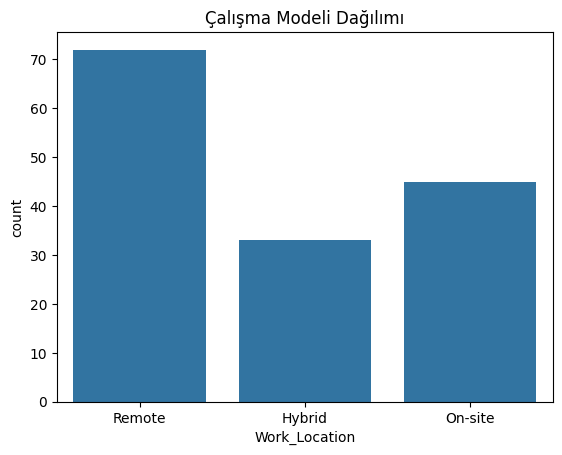

In [ ]:
sns.countplot(x="Work_Location", data=remote_df)

plt.title("Çalışma Modeli Dağılımı")

plt.show()

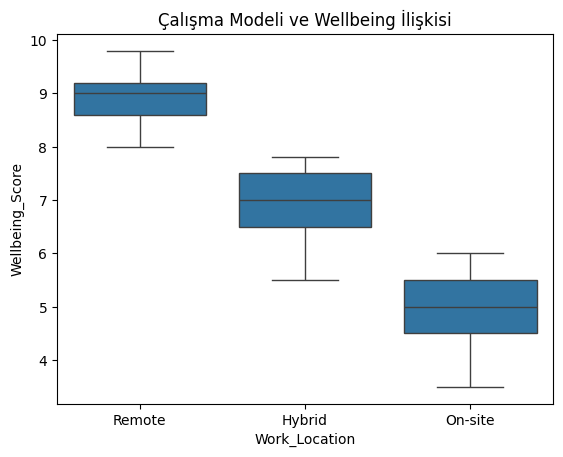

In [ ]:
sns.boxplot(
    x="Work_Location",
    y="Wellbeing_Score",
    data=remote_df
)

plt.title("Çalışma Modeli ve Wellbeing İlişkisi")

plt.show()
#Remote çalışanların refah seviyesi daha yüksek çıkmıştır.

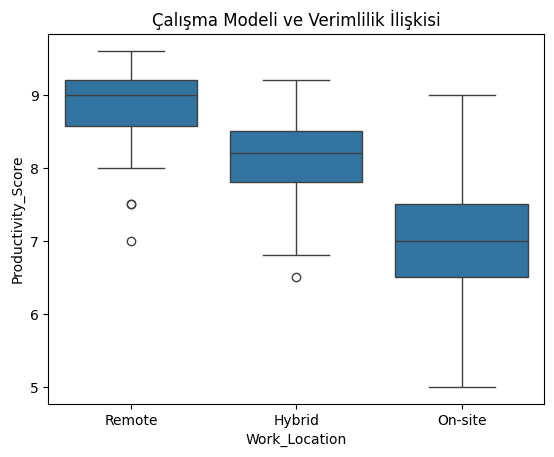

In [ ]:
sns.boxplot(
    x="Work_Location",
    y="Productivity_Score",
    data=remote_df
)

plt.title("Çalışma Modeli ve Verimlilik İlişkisi")

plt.show()
#Remote çalışanlar daha yüksek wellbeing,productivity gösteriyor.

In [ ]:
remote_df["AI_Usage"] = remote_df["AI_Tools_Used"].apply(
    lambda x: "AI Kullanıyor" if x != "No Ai Tools Used" else "AI Kullanmıyor"
)
remote_df["AI_Usage"].value_counts()

,count
AI_Usage,
AI Kullanıyor,100
AI Kullanmıyor,50


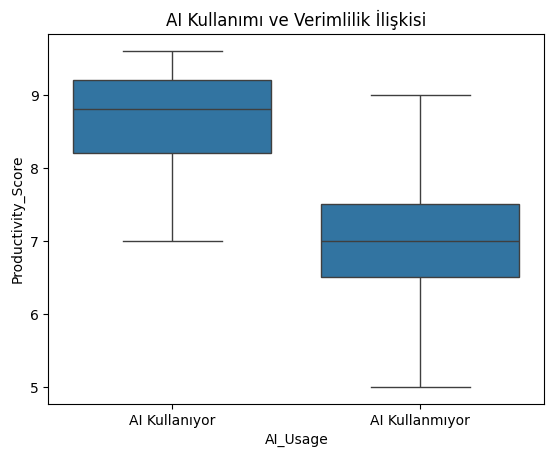

In [ ]:
sns.boxplot(
    x="AI_Usage",
    y="Productivity_Score",
    data=remote_df
)

plt.title("AI Kullanımı ve Verimlilik İlişkisi")

plt.show()
# Ai araçları kullanan çalışanların productivity skorlarının daha yüksek olduğu gözlemlenmiştir.
# Ai kullanmayan çalışanlarda daha düşük productivity değerleri görülmektedir.
# Bu durum Ai araçlarının çalışan verimliliği üzerinde olumlu etkileri olduğunu gösterir.

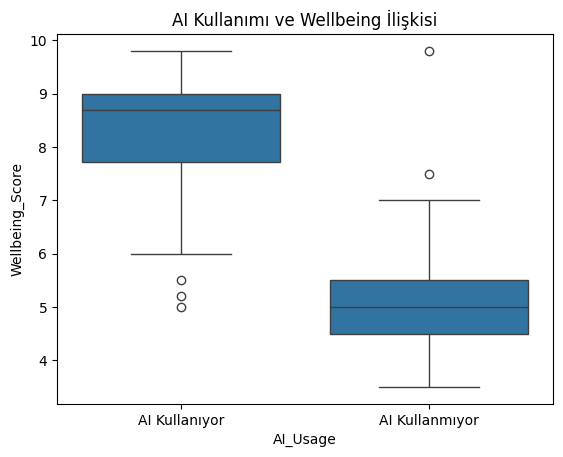

In [ ]:
sns.boxplot(
    x="AI_Usage",
    y="Wellbeing_Score",
    data=remote_df
)

plt.title("AI Kullanımı ve Wellbeing İlişkisi")

plt.show()
# Ai araçları kullanan çalışanların refah skorlarının daha yüksek olduğu gözlemlenmiştir.
# Bu sonuca göre Ai araçlarının çalışan memnuniyeti ve refahına olumlu katkı sağlayabileceğini göstermektedir.

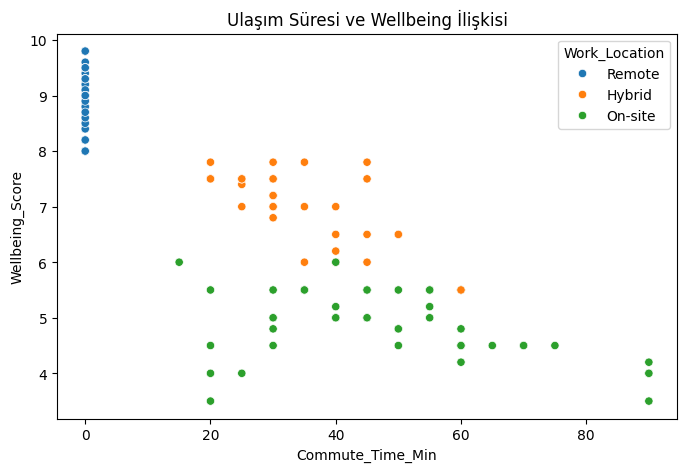

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Commute_Time_Min",
    y="Wellbeing_Score",
    hue="Work_Location",
    data=remote_df
)

plt.title("Ulaşım Süresi ve Wellbeing İlişkisi")

plt.show()
#Genel olarak ulaşım süresi arttıkça wellbeing düşüyor özellikle On-site çalışanlarda çok belirgin.
# Özellikle remote çalışanların ulaşım sürelerinin düşük ve wellbeing seviyelerinin yüksek olduğu görülmekte.
# Bu durum ulaşım süresinin çalışan yaşam kalitesi üzerinde olumsuz etkiler oluşturabileceğini göstermektedir.

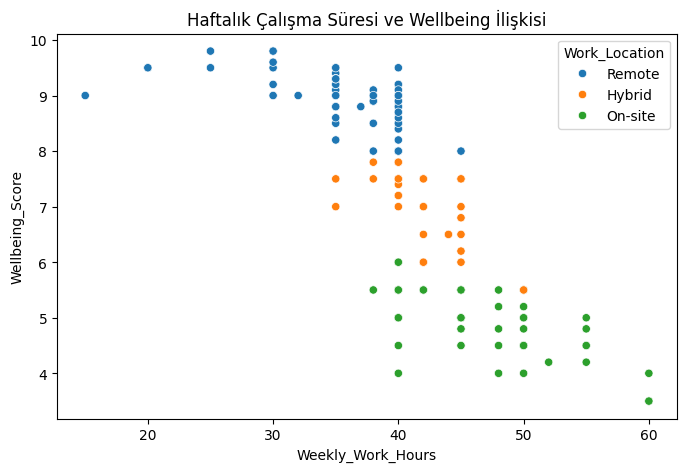

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Weekly_Work_Hours",
    y="Wellbeing_Score",
    hue="Work_Location",
    data=remote_df
)

plt.title("Haftalık Çalışma Süresi ve Wellbeing İlişkisi")

plt.show()
# Çalışma süresi arttıkça wellbeing düşüyor. Özellikle 50+ saat çalışanlarda wellbeing ciddi şekilde azalıyor.
# Remote çalışanlar daha düşük-orta çalışma saatlerinde bile yüksek wellbeingi koruyor.Yani Remote çalışma modeli çalışan psikolojisini koruyor olabilir.
# 40 saat civarı en dengeli bölge gibi görünüyor. Yani en optimum çalışma süresi olabilir.

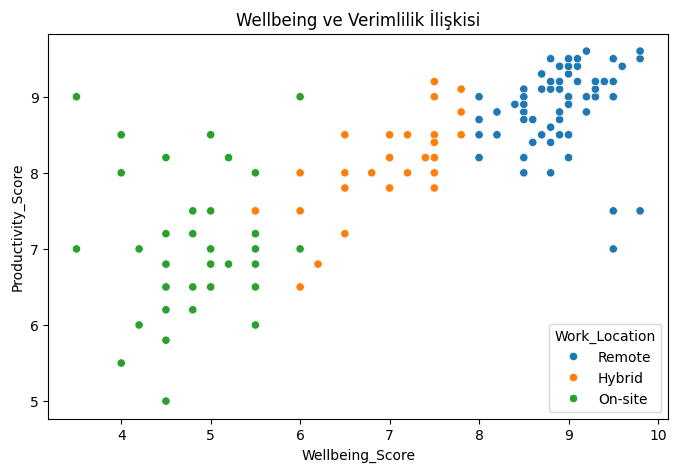

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Wellbeing_Score",
    y="Productivity_Score",
    hue="Work_Location",
    data=remote_df
)

plt.title("Wellbeing ve Verimlilik İlişkisi")

plt.show()
# Wellbeing'i yüksek çalışan, daha verimli çalıştığına ulaşılmıştır. Özellikle remote çalışanların. Sırasıyla Hybrid ve On-site şeklinde Wellbeing ve verimlilik düşüyor.

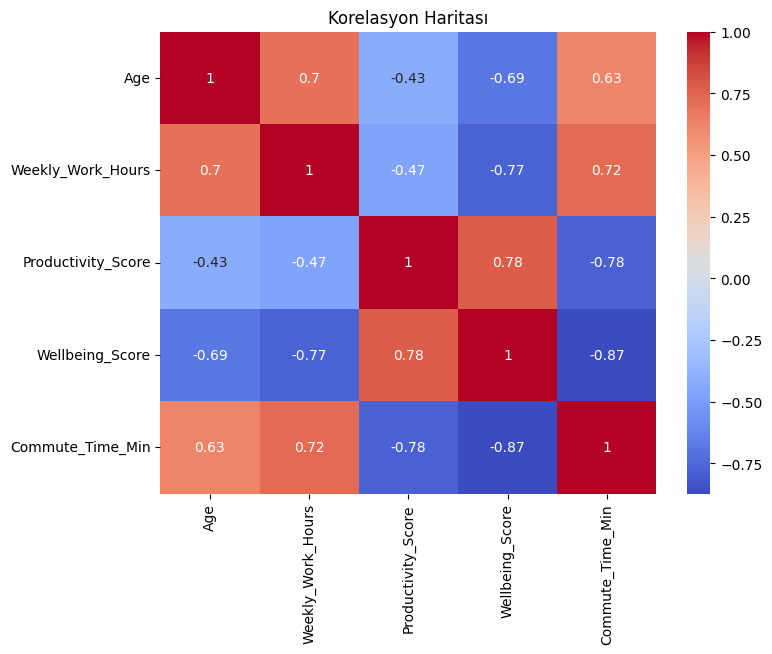

In [ ]:
numeric_df = remote_df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Korelasyon Haritası")

plt.show()
#Korelasyon analizi sonucunda wellbeing ve productivity skorları arasında güçlü pozitif ilişki var analiz ettiğimiz gibi.
# Ulaşım süresi uzadığında çalışan performansını ve yaşam kalitesini olumsuz etkilediği görülüyor.

In [ ]:
ai_location = pd.crosstab(
    remote_df["Work_Location"],
    remote_df["AI_Usage"]
)

ai_location

AI_Usage,AI Kullanmıyor,AI Kullanıyor
Work_Location,,
Hybrid,6,27
On-site,43,2
Remote,1,71


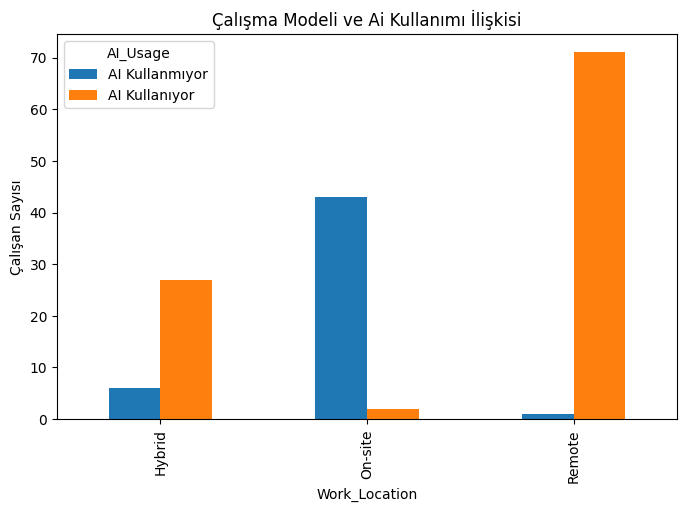

In [ ]:
ai_location.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Çalışma Modeli ve Ai Kullanımı İlişkisi")

plt.ylabel("Çalışan Sayısı")

plt.show()
#Remote çalışanların büyük çoğunluğu Ai kullanıyor. On-site çalışanların büyük çoğunluğu Ai kullanmıyor.


# AI Kullanımı, Çalışma Modelleri ve Çalışan Verimliliği Analizi

AI araç kullanımı, remote, hybrid ve ofisten çalışma modelleri ile çalışan wellbeing’i (refah/yaşam kalitesi), productivity’si (verimliliği) ve commute (ulaşım) süresi arasındaki ilişkilerin Python tabanlı veri analizi ve görselleştirme yöntemleri ile incelenmesi.
---

# Proje Amacı

Bu projenin amacı:

- çalışma modeli,
- AI araç kullanımı,
- commute (ulaşım) süresi,
- haftalık çalışma saati,
- wellbeing (refah/yaşam kalitesi) seviyesi

gibi değişkenlerin çalışan verimliliği üzerindeki etkilerini analiz etmektir.

---

# Kullanılan Teknolojiler

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

# Veri Seti İçeriği

Veri setinde çalışanlara ait:

- yaş,
- çalışma modeli,
- sektör,
- AI araç kullanımı,
- haftalık çalışma süresi,
- productivity (verimlilik) skoru,
- wellbeing (refah/yaşam kalitesi) skoru,
- commute (ulaşım) süresi

gibi bilgiler bulunmaktadır.

---

# Yapılan Analizler

Proje kapsamında:

- Veri temizleme işlemleri yapılmıştır
- Eksik veriler düzenlenmiştir
- Çalışma modeli dağılımları incelenmiştir
- AI kullanım analizleri gerçekleştirilmiştir
- Productivity (verimlilik) ve wellbeing (refah/yaşam kalitesi) ilişkileri analiz edilmiştir
- Korelasyon analizleri yapılmıştır
- Veri görselleştirme işlemleri uygulanmıştır

---

# Önemli Bulgular

## Remote (uzaktan) çalışanlar daha yüksek wellbeing (refah/yaşam kalitesi) seviyesine sahiptir

Analizler sonucunda remote (uzaktan) çalışanların wellbeing (refah/yaşam kalitesi) skorlarının diğer çalışma modellerine göre daha yüksek olduğu gözlemlenmiştir.

---

## Remote çalışanların productivity (verimlilik) seviyeleri daha yüksektir

Remote çalışanların productivity (verimlilik) skorlarının hybrid (hibrit) ve ofisten çalışanlara göre daha yüksek olduğu görülmüştür.

---

## AI araç kullanımı productivity (verimlilik) üzerinde olumlu etki göstermektedir

AI araçları kullanan çalışanların productivity (verimlilik) skorlarının daha yüksek olduğu gözlemlenmiştir.

---

## AI araçları wellbeing (refah/yaşam kalitesi) seviyesini destekleyebilir

AI kullanan çalışanların wellbeing (refah/yaşam kalitesi) skorlarının genel olarak daha yüksek olduğu görülmüştür.

---

## Commute (ulaşım) süresi wellbeing (refah/yaşam kalitesi) üzerinde olumsuz etki oluşturmaktadır

Commute (ulaşım) süresi arttıkça wellbeing (refah/yaşam kalitesi) ve productivity (verimlilik) skorlarının düştüğü gözlemlenmiştir.

Özellikle ofisten çalışanlarda daha düşük wellbeing (refah/yaşam kalitesi) seviyeleri dikkat çekmektedir.

---

## Wellbeing (refah/yaşam kalitesi) ve productivity (verimlilik) arasında güçlü ilişki bulunmaktadır.

Wellbeing (refah/yaşam kalitesi) seviyesi yüksek çalışanların productivity (verimlilik) skorlarının da daha yüksek olduğu görülmüştür.

---

# Genel Sonuç

Bu proje sonuçları:

- remote (uzaktan) çalışma modelinin,
- AI araç kullanımının,
- düşük commute (ulaşım) süresinin

çalışan wellbeing’i (refahı/yaşam kalitesi) ve productivity’si (verimliliği) üzerinde olumlu etkiler oluşturabileceğini göstermektedir.
